In [28]:
import pandas as pd
import numpy as np
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [2]:

LOCAL_PATH = "playground-series-s6e4"

if os.path.exists("/kaggle/input/playground-series-s6e4"):
    # Running on Kaggle
    train = pd.read_csv("/kaggle/input/playground-series-s6e4/train.csv")
    test = pd.read_csv("/kaggle/input/playground-series-s6e4/test.csv")
else:
    # Running locally
    train = pd.read_csv(f"{LOCAL_PATH}/train.csv")
    test = pd.read_csv(f"{LOCAL_PATH}/test.csv")

In [8]:

y_le = LabelEncoder()
y = y_le.fit_transform(train["Irrigation_Need"])

X_train = train.drop(columns=["Irrigation_Need", "id"])
X_test = test.drop(columns=["id"])

for df in [X_train, X_test]:
    df["temp_moisture"] = df["Temperature_C"] * df["Soil_Moisture"]
    df["wind_moisture"] = df["Wind_Speed_kmh"] * df["Soil_Moisture"]
    df["temp_wind"] = df["Temperature_C"] * df["Wind_Speed_kmh"]
    
    df["temp_sq"] = df["Temperature_C"] ** 2
    df["soil_moisture_sq"] = df["Soil_Moisture"] ** 2

X_train_encoded = pd.get_dummies(X_train, drop_first=False)
X_test_encoded = pd.get_dummies(X_test, drop_first=False)

X_train_encoded, X_test_encoded = X_train_encoded.align(
    X_test_encoded,
    join="left",
    axis=1,
    fill_value=0
)

print(X_train_encoded.shape)
print(X_test_encoded.shape)

(630000, 48)
(270000, 48)


In [19]:

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rf_scores = cross_val_score(
    rf,
    X_train_encoded,
    y,
    cv=cv,
    scoring="balanced_accuracy"
)

print("RF Balanced Accuracy:", rf_scores.mean())

RF Balanced Accuracy: 0.9532795471191576


In [ ]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss"
)

# Cross validation
xgb_scores = cross_val_score(
    xgb,
    X_train_encoded,
    y,
    cv=cv,
    scoring="balanced_accuracy",
    n_jobs=-1
)

print("XGBoost Balanced Accuracy:", xgb_scores.mean())
print("Fold Scores:", xgb_scores)

XGBoost Balanced Accuracy: 0.9618203479221445
Fold Scores: [0.96068012 0.96285746 0.9620762  0.96222967 0.96125829]


In [22]:

rf_grid = {
    "n_estimators": [200],
    "max_depth": [None, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt"],
    "bootstrap": [True]
}

rf_tune_model = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_tune_cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

rf_grid_search = GridSearchCV(
    estimator=rf_tune_model,
    param_grid=rf_grid,
    scoring="balanced_accuracy",
    cv=rf_tune_cv,
    n_jobs=-1,
    verbose=2
)

rf_grid_search.fit(X_train_encoded, y)

print("RF Best Params:", rf_grid_search.best_params_)
print("RF Best CV Balanced Accuracy:", rf_grid_search.best_score_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warn

[CV] END bootstrap=True, max_depth=None, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=200; total time= 6.5min


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warn

[CV] END bootstrap=True, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time= 6.6min


...

[CV] END bootstrap=True, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=200; total time= 6.6min


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warn

[CV] END bootstrap=True, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time= 6.6min


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warn

[CV] END bootstrap=True, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time= 6.7min
[CV] END bootstrap=True, max_depth=20, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time= 6.1min
[CV] END bootstrap=True, max_depth=20, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time= 6.1min
[CV] END bootstrap=True, max_depth=None, max_features=sqrt, min_samples_leaf=2, min_samples_split=5, n_estimators=200; total time= 6.2min
[CV] END bootstrap=True, max_depth=None, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=200; total time= 6.2min
[CV] END bootstrap=True, max_depth=20, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time= 6.2min
[CV] END bootstrap=True, max_depth=20, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=200; total time= 6.1min
[CV] END bootstrap=True, max_depth=None, m

In [21]:
# Separate tuning cell for XGBoost (keeps baseline model above unchanged)
xgb_grid = {
    "n_estimators": [200, 300],
    "max_depth": [4, 6],
    "learning_rate": [0.05, 0.1],
}

xgb_tune_model = XGBClassifier(
    random_state=42,
    eval_metric="mlogloss",
    tree_method="hist",
    n_jobs=-1
)

xgb_tune_cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

xgb_grid_search = GridSearchCV(
    estimator=xgb_tune_model,
    param_grid=xgb_grid,
    scoring="balanced_accuracy",
    cv=xgb_tune_cv,
    n_jobs=-1,
    verbose=2
)

xgb_grid_search.fit(X_train_encoded, y)

print("XGB Best Params:", xgb_grid_search.best_params_)
print("XGB Best CV Balanced Accuracy:", xgb_grid_search.best_score_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
[CV] END ..learning_rate=0.05, max_depth=4, n_estimators=200; total time=  50.5s
[CV] END ..learning_rate=0.05, max_depth=4, n_estimators=200; total time=  51.2s
[CV] END ..learning_rate=0.05, max_depth=4, n_estimators=200; total time=  54.1s
[CV] END ..learning_rate=0.05, max_depth=6, n_estimators=200; total time= 1.1min
[CV] END ..learning_rate=0.05, max_depth=6, n_estimators=200; total time= 1.1min
[CV] END ..learning_rate=0.05, max_depth=4, n_estimators=300; total time= 1.2min
[CV] END ..learning_rate=0.05, max_depth=4, n_estimators=300; total time= 1.2min
[CV] END ..learning_rate=0.05, max_depth=4, n_estimators=300; total time= 1.2min
[CV] END ..learning_rate=0.05, max_depth=6, n_estimators=200; total time=  54.1s
[CV] END ...learning_rate=0.1, max_depth=4, n_estimators=200; total time=  39.8s
[CV] END ...learning_rate=0.1, max_depth=4, n_estimators=200; total time=  39.5s
[CV] END ...learning_rate=0.1, max_depth=4, n_est

In [25]:

xgb_best = xgb_grid_search.best_estimator_
rf_best = rf_grid_search.best_estimator_

# Fit on full training data
xgb_best.fit(X_train_encoded, y)
rf_best.fit(X_train_encoded, y)

# Predict
xgb_preds = xgb_best.predict(X_test_encoded)
rf_preds = rf_best.predict(X_test_encoded)

# Load sample submission
sample_submission = pd.read_csv("playground-series-s6e4/sample_submission.csv")

# Create Output folder
output_path = "Output"
os.makedirs(output_path, exist_ok=True)

# XGBoost submission
xgb_submission = sample_submission.copy()
xgb_submission["Irrigation_Need"] = y_le.inverse_transform(xgb_preds)
xgb_submission.to_csv(f"{output_path}/xgb_submission.csv", index=False)

# Random Forest submission
rf_submission = sample_submission.copy()
rf_submission["Irrigation_Need"] = y_le.inverse_transform(rf_preds)
rf_submission.to_csv(f"{output_path}/rf_submission.csv", index=False)

print("Files saved to Output folder:")
print(f"- {output_path}/xgb_submission.csv")
print(f"- {output_path}/rf_submission.csv")

Files saved to Output folder:
- Output/xgb_submission.csv
- Output/rf_submission.csv


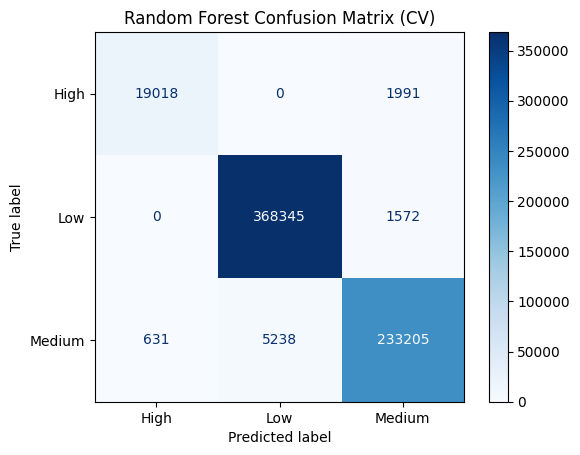

In [29]:
rf_best = rf_grid_search.best_estimator_

rf_preds_cv = cross_val_predict(
    rf_best,
    X_train_encoded,
    y,
    cv=3,
    n_jobs=-1
)

rf_cm = confusion_matrix(y, rf_preds_cv)

disp = ConfusionMatrixDisplay(
    confusion_matrix=rf_cm,
    display_labels=y_le.classes_
)

disp.plot(cmap="Blues")
plt.title("Random Forest Confusion Matrix (CV)")
plt.show()

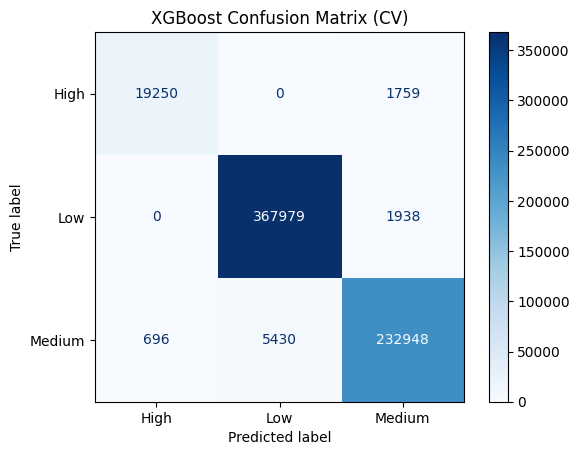

In [30]:
xgb_best = xgb_grid_search.best_estimator_

xgb_preds_cv = cross_val_predict(
    xgb_best,
    X_train_encoded,
    y,
    cv=3,
    n_jobs=-1
)

xgb_cm = confusion_matrix(y, xgb_preds_cv)

disp = ConfusionMatrixDisplay(
    confusion_matrix=xgb_cm,
    display_labels=y_le.classes_
)

disp.plot(cmap="Blues")
plt.title("XGBoost Confusion Matrix (CV)")
plt.show()